# 效果演示

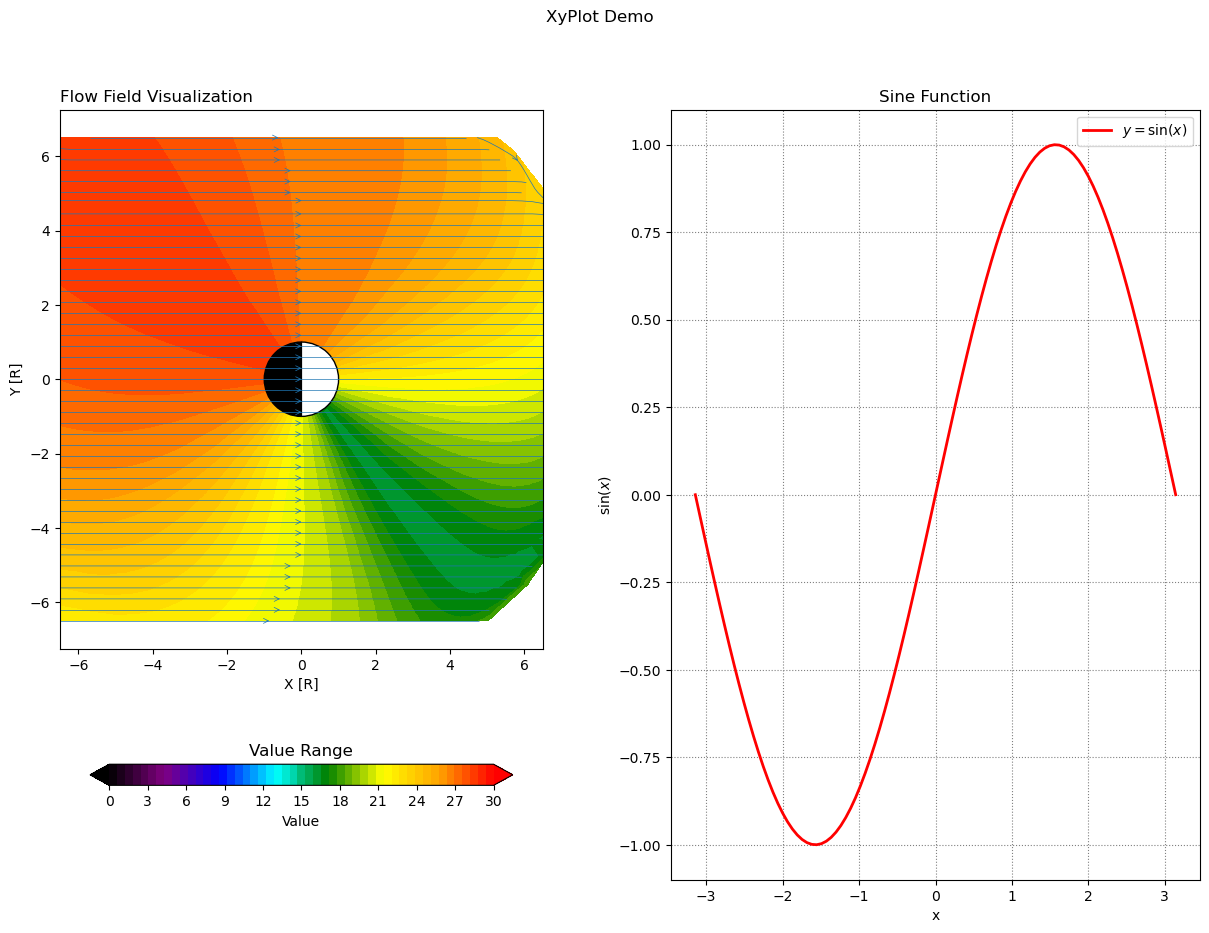

In [3]:
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
from xyplot import XyPlot
from utils import read_data, create_flow_field_config

try:
    # 读取数据文件
    file = r"data/P-L1-IMM-SWMF_20221018004619_0005M_SWMF.dat"
    df = read_data(file)
    
    # 网格数据准备
    x, y = df['X [R]'].values, df['Y [R]'].values
    xx = yy = np.linspace(-6.5, 6.5, 1000)
    X, Y = np.meshgrid(xx, yy)
    grid_data = griddata((x, y), df[df.keys()[7]].values, (X, Y), method="linear")
    U = griddata((x, y), df[df.keys()[8]].values, (X, Y), method="linear")
    V = griddata((x, y), df[df.keys()[9]].values, (X, Y), method="linear")
    
    # 创建流场配置
    cfg = create_flow_field_config(X, Y, U, V, grid_data)
    
    # 创建正弦图配置
    x_sin = np.linspace(-np.pi, np.pi, 100)
    y_sin = np.sin(x_sin)
    cfg_sin = dict(
        title=dict(args="Sine Function", loc='center'),
        xlabel=dict(args="x", c='k'),
        ylabel=dict(args=r'$\sin(x)$', c='k'),
        plot=dict(args=(x_sin, y_sin), label=r'$y = \sin(x)$', c='r', lw=2),
        grid=dict(linestyle=':', color='gray'),
        legend=dict(loc='upper right'),
    )
    
    # 设置图表参数
    fig_dict = dict(
        height=10, width=15,
        title=dict(args='XyPlot Demo'),
    )
    
    # 创建多子图布局
    axes_dict = dict(
        set_fig=fig_dict,
        axes=dict(
            init=(dict(args=(1, 2, 1), ), 122),
            axes=(cfg, cfg_sin)
        )
    )
    
    # 创建并显示图表
    xy_plot = XyPlot(**axes_dict)
    xy_plot.show()
    
except Exception as e:
    # 如果数据文件不存在，只显示简单的正弦图
    print(f"注意: {e}")
    print("显示基本正弦图示例...")
    
    x = np.linspace(-np.pi, np.pi, 100)
    y = np.sin(x)
    
    set_fig_dict = dict(height=8, width=10)
    axes_dict = dict(
        plot=dict(args=(x, y), label='y=sin(x)', c='r', lw=2),
        title=r'y=sin(x)',
        grid=dict(linestyle=':', color='gray'),
        xlabel="x",
        ylabel="y",
        legend=dict(loc='upper right'),
    )
    
    cfg = dict(set_fig=set_fig_dict, axes=axes_dict)
    xyplt = XyPlot(**cfg)
    xyplt.show()
